In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

Dataset: <br>
League - New All, Expanded Features <br>
Year(s) - 2021-25 <br>

In [9]:
# Test new set loading / verify the same format compared to original Final_DataSet_All_Fixed.csv
# df = pd.read_csv('../data/v4/All_Data_Final.csv')
# df

In [10]:
# --- 1. DATA PREPARATION ---
df = pd.read_csv('../data/v4/All_Data_Final.csv')
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
if 'Unnamed: 0.1' in df.columns:
    df.drop('Unnamed: 0.1', axis=1, inplace=True)

df['Game_ID'] = df['Game_ID'].astype(str)

# OUTCOME MAPPING (From 'Final Result' events)
final_results = df[df['Event_Type'] == 'Final Result'].copy()
conditions = [
    (final_results['Home_Score'] > final_results['Away_Score']),
    (final_results['Away_Score'] > final_results['Home_Score']),
    (final_results['Home_Score'] == final_results['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
final_results['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')

outcome_map = dict(zip(final_results['Game_ID'], final_results['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

# Clean and Filter
df = df.dropna(subset=['Match_Outcomes'])
df = df[df['Match_Outcomes'] != 'Unknown'].copy()
df_mod = df[df['Event_Type'] != 'Final Result'].copy()

# Feature Engineering
df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])
df_mod['Home_Odds_Log'] = np.log1p(df_mod['Odds_Home_Win'].fillna(0))
df_mod['Draw_Odds_Log'] = np.log1p(df_mod['Odds_Draw'].fillna(0))
df_mod['Away_Odds_Log'] = np.log1p(df_mod['Odds_Away_Win'].fillna(0))
df_mod['Time_Bin'] = (df_mod['Time'] // 5).astype(int)

outcome_colors = {'Home_Win': "#4b5dd6", 'Away_Win': "#b44a04", 'Draw': "#dddddd8f"}

In [11]:
# PART A: NORMAL TIME ANALYSIS (STAGES 1, 2, 3)
# =================================================================
print("--- PART A: NORMAL TIME ---")
features_n = ['Time', 'Score_Diff', 'Home_Score_Log', 'Away_Score_Log', 'Home_Red_Count', 
              'Away_Red_Count', 'Home_Yellow_Count', 'Away_Yellow_Count', 'Home_Sub_Count', 
              'Away_Sub_Count', 'Home_Odds_Log', 'Draw_Odds_Log', 'Away_Odds_Log']

X_n = df_mod[features_n]
y_n = df_mod['Match_Outcomes']
X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(X_n, y_n, test_size=0.2, random_state=42, stratify=y_n)

--- PART A: NORMAL TIME ---


In [12]:
# Stage 1: Baseline
base_n = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=2)), ('knn', KNeighborsClassifier(n_neighbors=15))])
base_n.fit(X_tr_n, y_tr_n)

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'


In [13]:
# Stage 2: Optimized (SMOTE)
smote_n = ImbPipeline([('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)), ('pca', PCA(n_components=6)), ('knn', KNeighborsClassifier(weights='distance'))])
smote_n.fit(X_tr_n, y_tr_n)
y_pred_n = smote_n.predict(X_te_n)

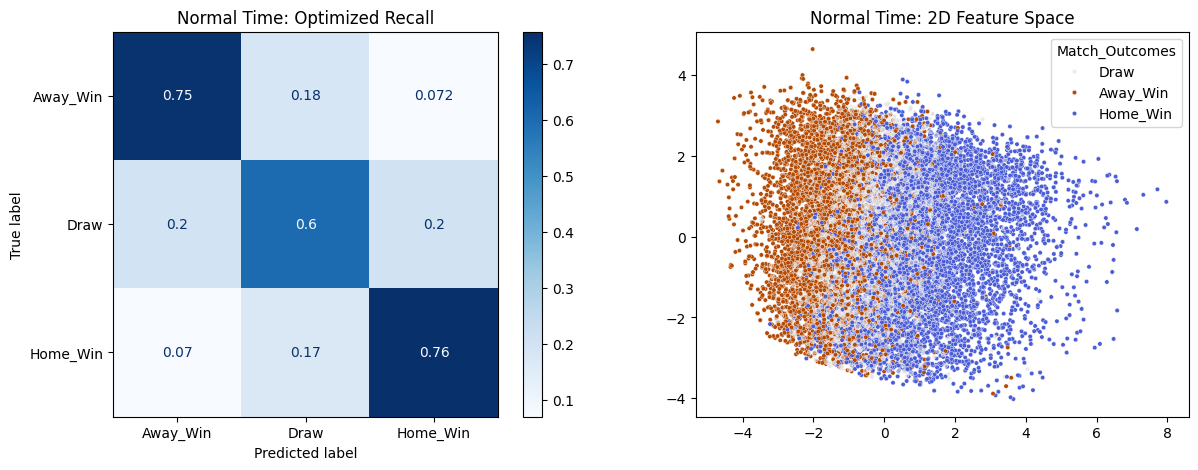

In [14]:
# Visualizations A
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_te_n, y_pred_n, cmap='Blues', normalize='true', ax=ax[0])
ax[0].set_title("Normal Time: Optimized Recall")
X_pca_n = base_n.named_steps['pca'].transform(base_n.named_steps['scaler'].transform(X_te_n))
sns.scatterplot(x=X_pca_n[:, 0], y=X_pca_n[:, 1], hue=y_te_n, palette=outcome_colors, s=10, ax=ax[1])
ax[1].set_title("Normal Time: 2D Feature Space")
plt.show()

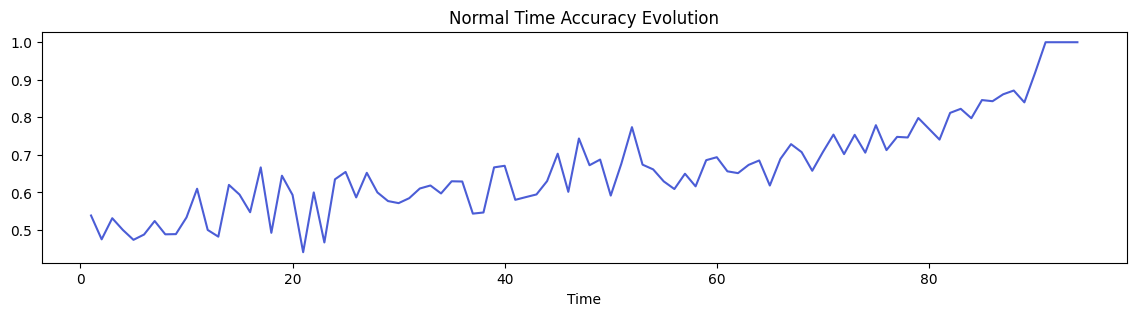

In [15]:
# Stage 3: Accuracy Evolution
acc_n = X_te_n.copy()
acc_n['A'], acc_n['P'] = y_te_n, y_pred_n
plt.figure(figsize=(14, 3))
acc_n.groupby('Time').apply(lambda x: accuracy_score(x['A'], x['P']), include_groups=False).plot(color='#4b5dd6')
plt.title("Normal Time Accuracy Evolution")
plt.show()

In [16]:
# PART B: BINNED TIME ANALYSIS (STAGES 4, 5, 6)
# =================================================================
print("\n--- PART B: BINNED TIME ---")
features_b = [f if f != 'Time' else 'Time_Bin' for f in features_n]
X_b = df_mod[features_b]
y_b = df_mod['Match_Outcomes']
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(X_b, y_b, test_size=0.2, random_state=42, stratify=y_b)


--- PART B: BINNED TIME ---


In [17]:
# Stage 4: Baseline
base_b = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=2)), ('knn', KNeighborsClassifier(n_neighbors=15))])
base_b.fit(X_tr_b, y_tr_b)

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'


In [18]:
# Stage 5: Optimized (SMOTE)
smote_b = ImbPipeline([('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)), ('pca', PCA(n_components=6)), ('knn', KNeighborsClassifier(weights='distance'))])
smote_b.fit(X_tr_b, y_tr_b)
y_pred_b = smote_b.predict(X_te_b)

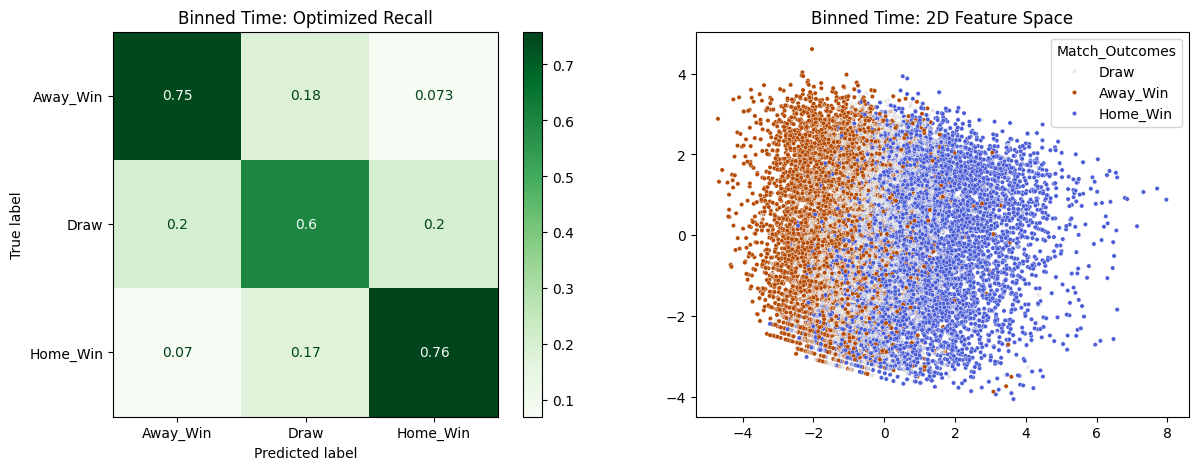

In [20]:
# Visualizations B
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_te_b, y_pred_b, cmap='Greens', normalize='true', ax=ax[0])
ax[0].set_title("Binned Time: Optimized Recall")
X_pca_b = base_b.named_steps['pca'].transform(base_b.named_steps['scaler'].transform(X_te_b))
sns.scatterplot(x=X_pca_b[:, 0], y=X_pca_b[:, 1], hue=y_te_b, palette=outcome_colors, s=10, ax=ax[1])
ax[1].set_title("Binned Time: 2D Feature Space")
plt.show()

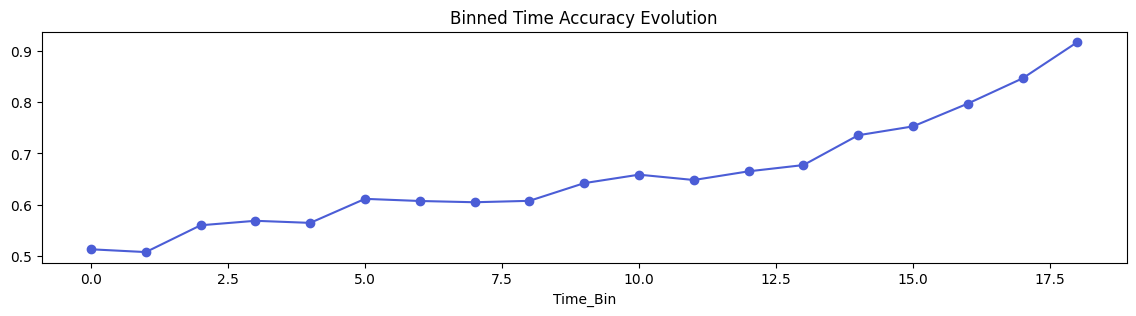

In [21]:
# Stage 6: Accuracy Evolution
acc_b = X_te_b.copy()
acc_b['A'], acc_b['P'] = y_te_b, y_pred_b
plt.figure(figsize=(14, 3))
acc_b.groupby('Time_Bin').apply(lambda x: accuracy_score(x['A'], x['P']), include_groups=False).plot(kind='line', marker='o', color='#4b5dd6')
plt.title("Binned Time Accuracy Evolution")
plt.show()


--- STAGE 7: COMPREHENSIVE FEATURE MAPPING ---


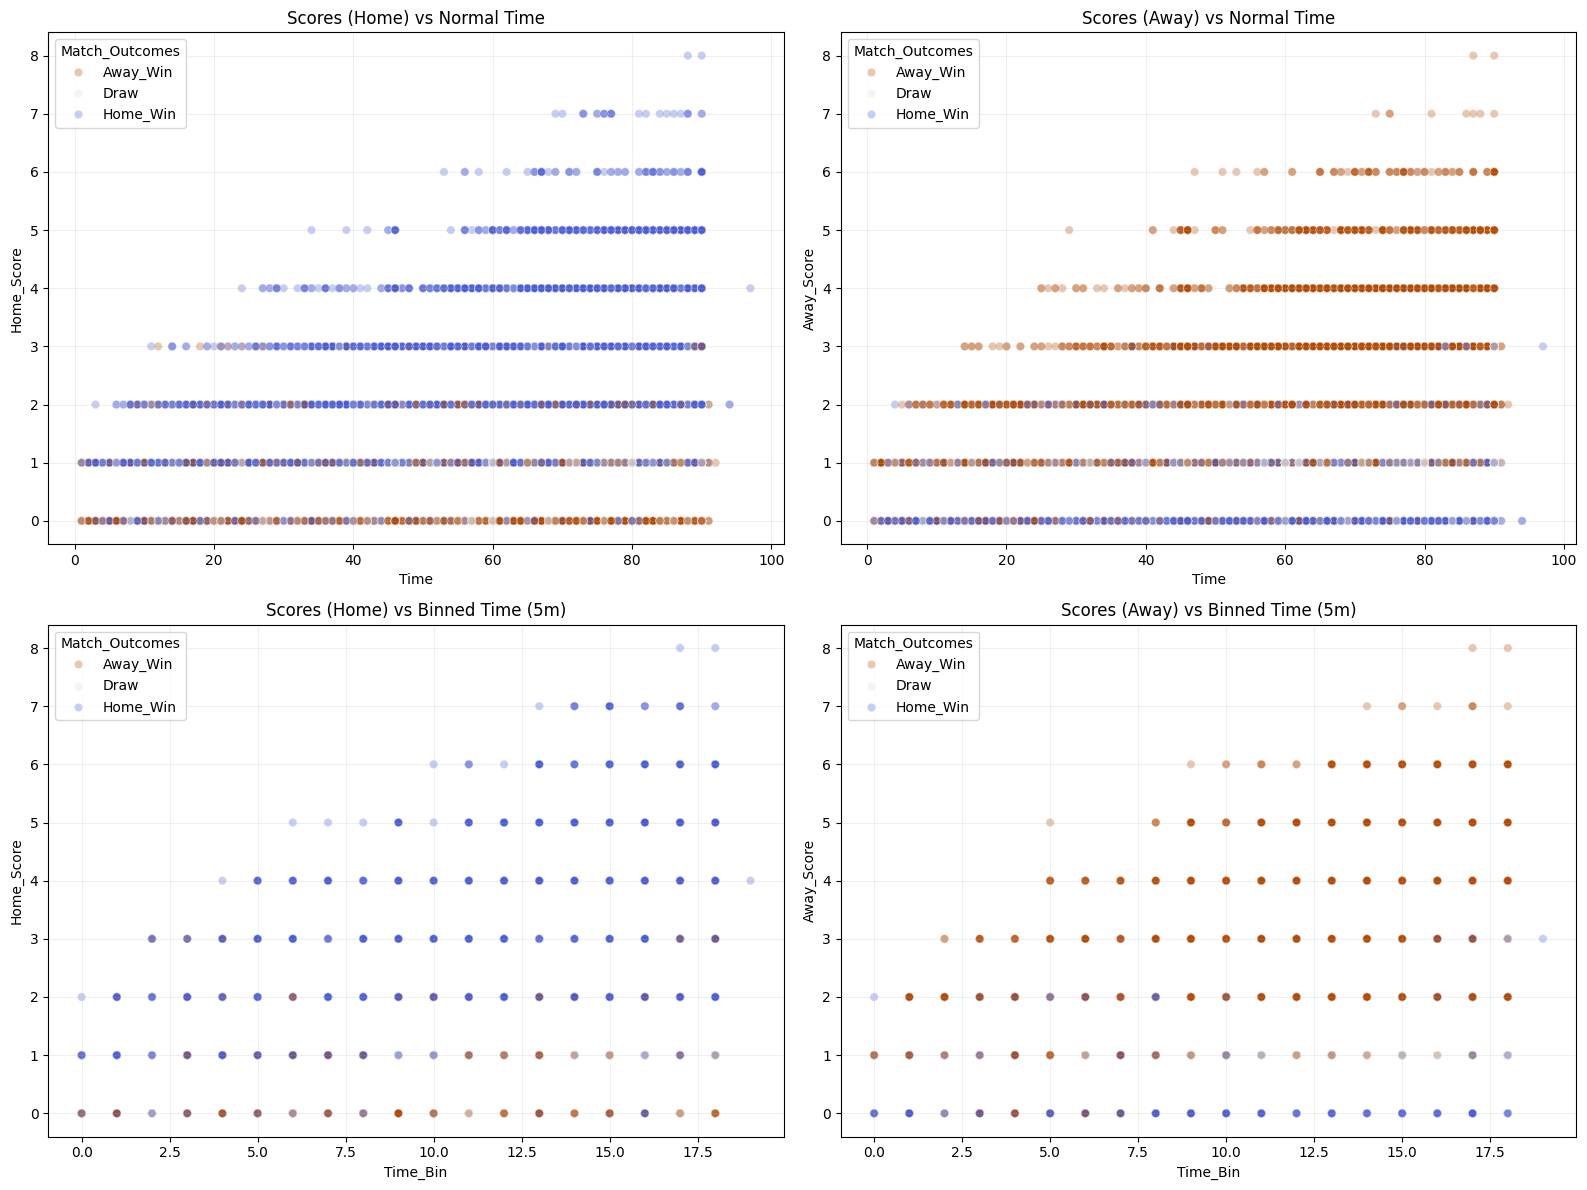

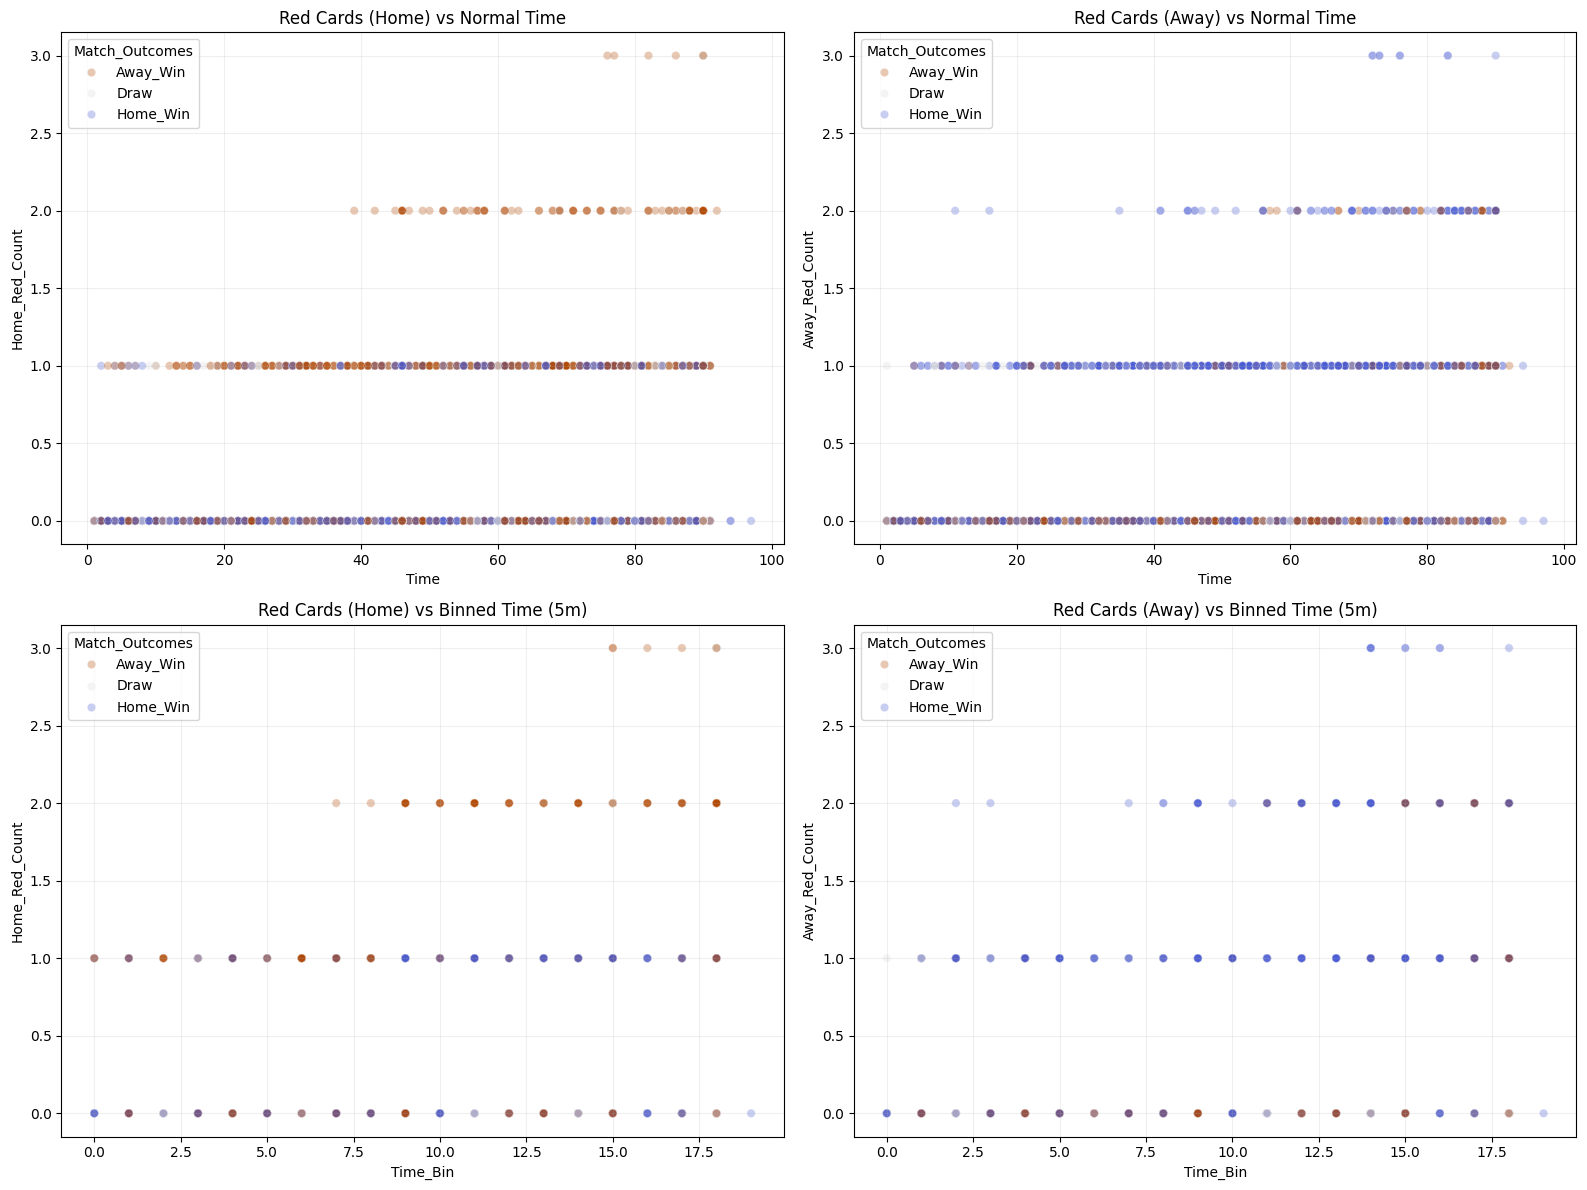

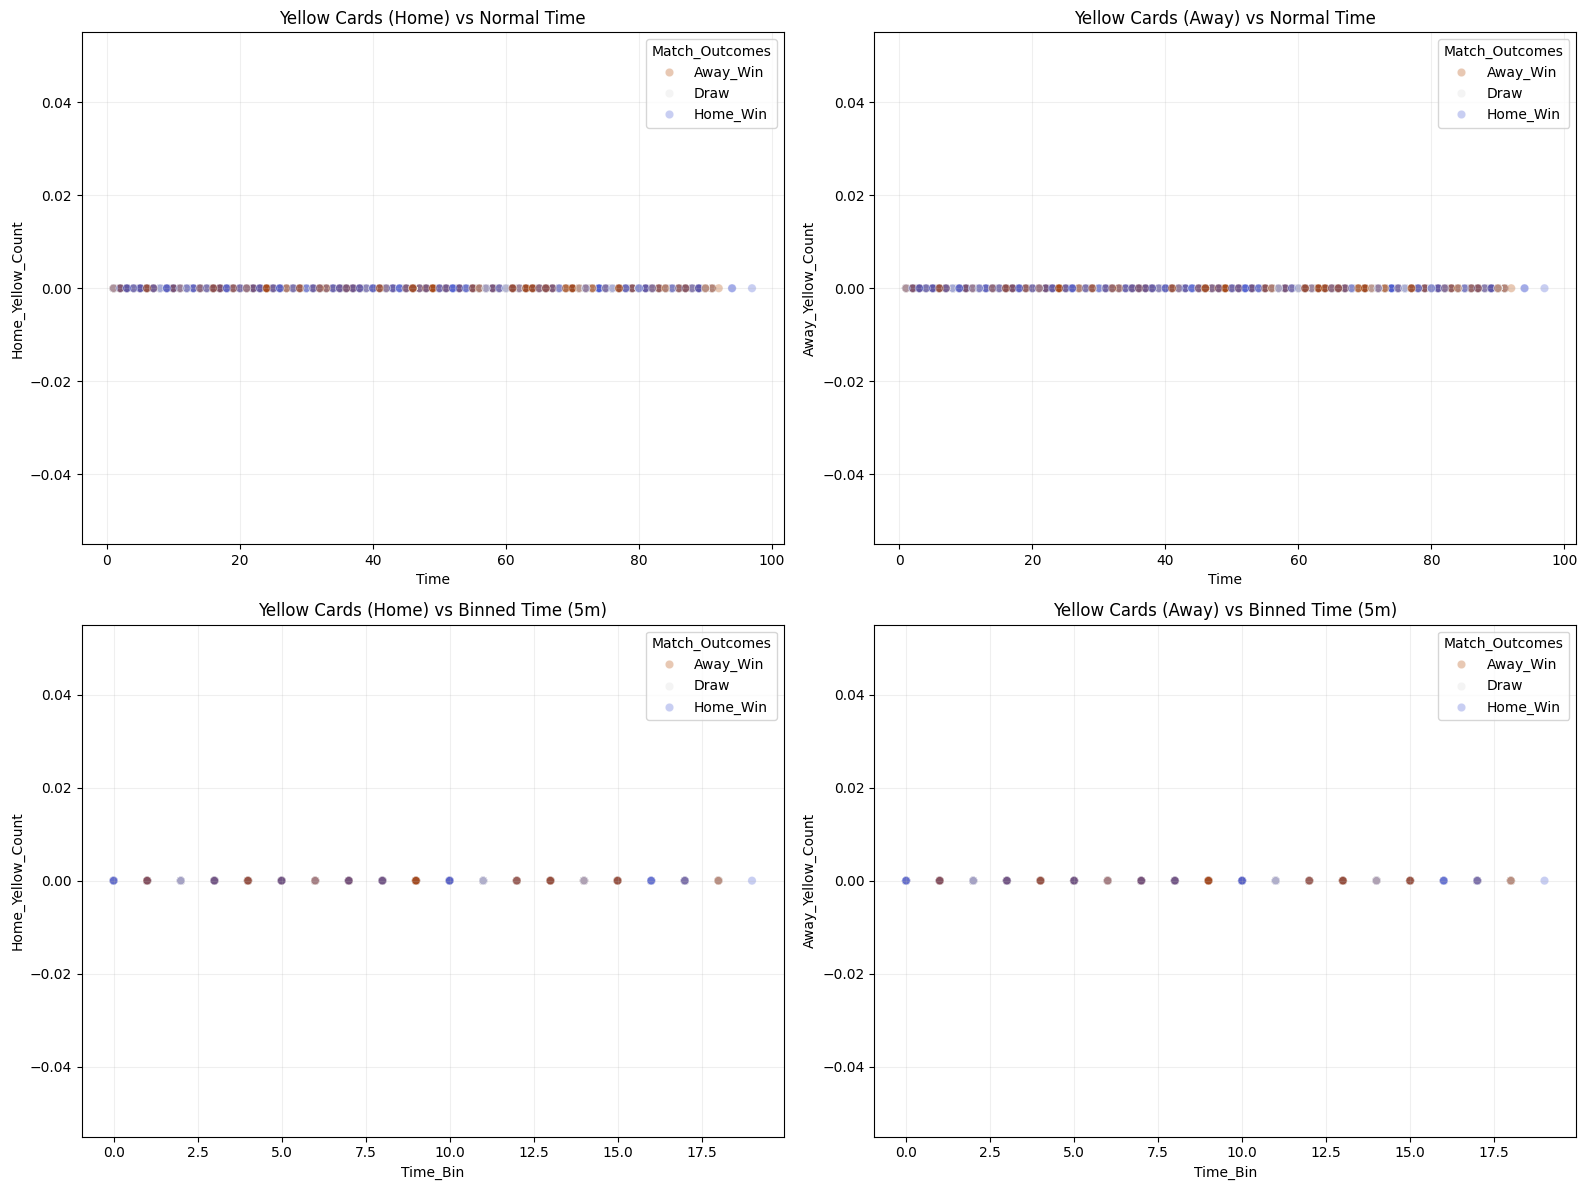

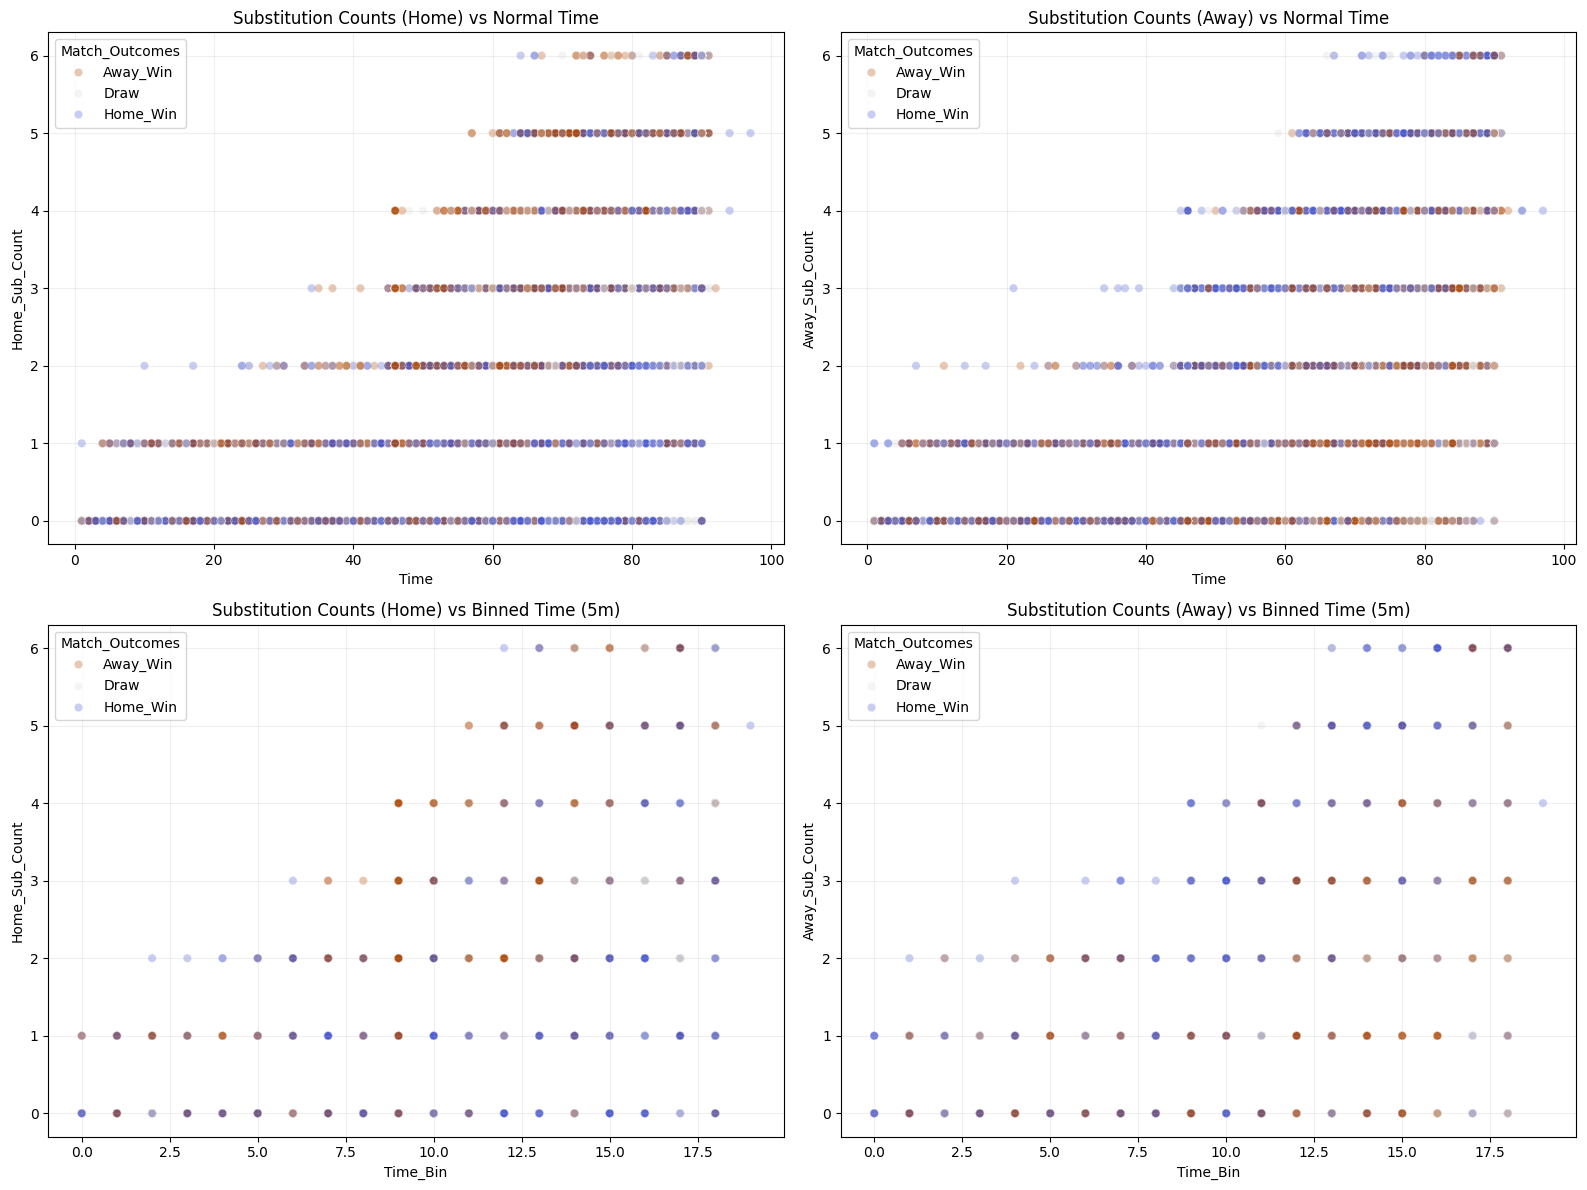

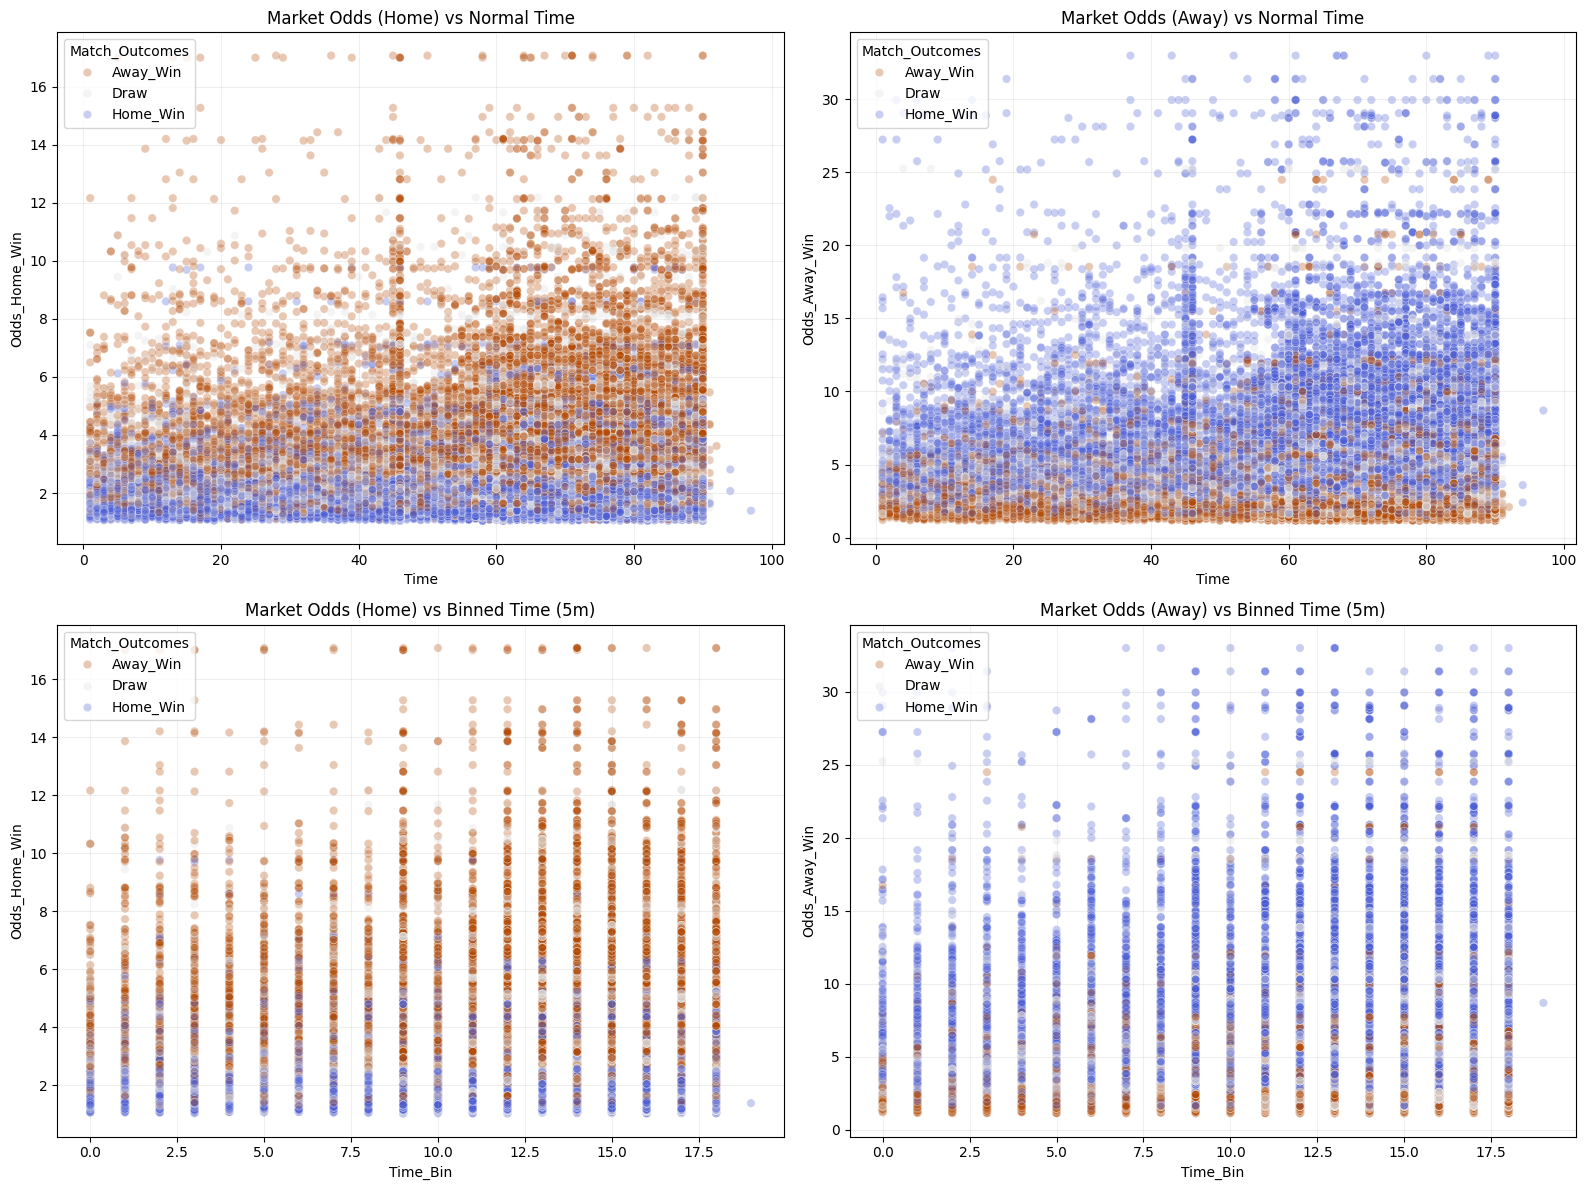

C:\Users\matth\AppData\Local\Temp\ipykernel_23416\1701613698.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.importances_mean, y=features_b, palette='mako')


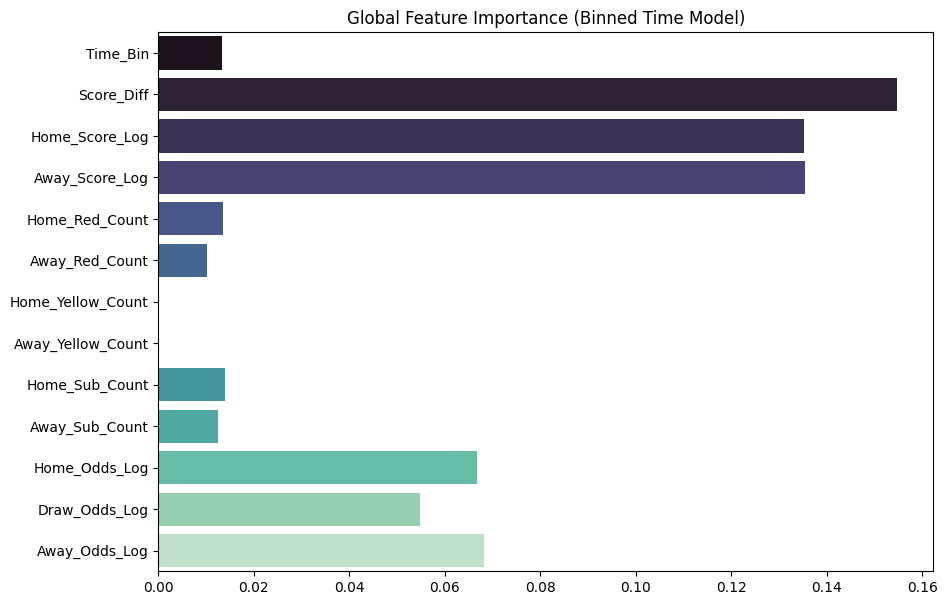


REASONING:
The 2x2 grids in Stage 7 allow us to see how each feature set contributes to the 'islands'
of outcome. Binned time provides the tactical structure (columns), while the features
themselves provide the outcome density within those columns.


In [22]:
# STAGE 7: COMPREHENSIVE FEATURE MAPPING (All Features vs Time)
# =================================================================
print("\n--- STAGE 7: COMPREHENSIVE FEATURE MAPPING ---")

def plot_feature_grid_full(h_feat, a_feat, title_name):
    """Generates a 2x2 grid for a feature pair: Normal vs Binned Time."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=False)
    
    # Row 1: Normal Time
    sns.scatterplot(data=df_mod, x="Time", y=h_feat, hue="Match_Outcomes", 
                    palette=outcome_colors, alpha=0.3, ax=axes[0, 0])
    axes[0, 0].set_title(f"{title_name} (Home) vs Normal Time")
    
    sns.scatterplot(data=df_mod, x="Time", y=a_feat, hue="Match_Outcomes", 
                    palette=outcome_colors, alpha=0.3, ax=axes[0, 1])
    axes[0, 1].set_title(f"{title_name} (Away) vs Normal Time")
    
    # Row 2: Binned Time
    sns.scatterplot(data=df_mod, x="Time_Bin", y=h_feat, hue="Match_Outcomes", 
                    palette=outcome_colors, alpha=0.3, ax=axes[1, 0])
    axes[1, 0].set_title(f"{title_name} (Home) vs Binned Time (5m)")
    
    sns.scatterplot(data=df_mod, x="Time_Bin", y=a_feat, hue="Match_Outcomes", 
                    palette=outcome_colors, alpha=0.3, ax=axes[1, 1])
    axes[1, 1].set_title(f"{title_name} (Away) vs Binned Time (5m)")
    
    for ax_flat in axes.flat:
        ax_flat.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

# Mapping all features against the match clock
plot_feature_grid_full("Home_Score", "Away_Score", "Scores")
plot_feature_grid_full("Home_Red_Count", "Away_Red_Count", "Red Cards")
plot_feature_grid_full("Home_Yellow_Count", "Away_Yellow_Count", "Yellow Cards")
plot_feature_grid_full("Home_Sub_Count", "Away_Sub_Count", "Substitution Counts")
plot_feature_grid_full("Odds_Home_Win", "Odds_Away_Win", "Market Odds")

# Final Global Feature Importance
imp = permutation_importance(smote_b, X_te_b, y_te_b, n_repeats=5, random_state=42)
plt.figure(figsize=(10, 7))
sns.barplot(x=imp.importances_mean, y=features_b, palette='mako')
plt.title("Global Feature Importance (Binned Time Model)")
plt.show()

print("\nREASONING:")
print("The 2x2 grids in Stage 7 allow us to see how each feature set contributes to the 'islands'")
print("of outcome. Binned time provides the tactical structure (columns), while the features")
print("themselves provide the outcome density within those columns.")